In [2]:
# 安装必要的库（如果尚未安装）
import sys
!{sys.executable} -m pip install torch torchvision torchaudio -i https://pypi.tuna.tsinghua.edu.cn/simple

# 设置matplotlib在notebook中内联显示
%matplotlib inline

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple


In [3]:
import time
import torch
from torch import nn, optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 数据预处理
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),  # 预训练模型需要 224x224 输入
    transforms.RandomHorizontalFlip(),  # 随机水平翻转（数据增强）
    transforms.RandomRotation(15),  # 随机旋转 ±15 度
    transforms.ColorJitter(brightness=0.2, contrast=0.2),  # 亮度/对比度变化
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ImageNet 统计的均值和
                         std=[0.229, 0.224, 0.225])
])

# 加载数据集
data_dir = './data/PlantVillage'
try:
    full_dataset = datasets.ImageFolder(root=data_dir, transform=train_transform)
    print(f'成功加载本地数据，共 {len(full_dataset)} 张图片')

    # 查看类别
    class_names = full_dataset.classes
    num_classes = len(class_names)
    print(f'类别数量: {num_classes}')
    print(f'类别名称: {class_names}')

except FileNotFoundError:
    print('警告: PlantVillage数据集未找到，创建模拟数据集进行演示')

    # 使用默认类别数
    num_classes = 4  # 番茄病害类别数
    class_names = [f'class_{i}' for i in range(num_classes)]

    # 创建模拟数据集
    num_samples = 100
    img_size = (3, 224, 224)

    # 生成随机图像数据
    images = torch.randn(num_samples, *img_size)
    labels = torch.randint(0, num_classes, (num_samples,))

    # 创建TensorDataset
    from torch.utils.data import TensorDataset
    full_dataset = TensorDataset(images, labels)
    print(f'创建模拟数据集: {num_samples} 个样本，{num_classes} 个类别')

# 分割数据集为训练集和验证集
train_size = int(0.7 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

print(f"训练集大小: {len(train_dataset)}")
print(f"验证集大小: {len(val_dataset)}")

# 创建数据加载器
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print(f"数据加载器创建完成，批量大小: {batch_size}")


def train_model(model, criterion, optimizer, epochs=5, name=""):
    """通用训练函数"""
    train_losses, val_accs = [], []
    start_time = time.time()

    for epoch in range(epochs):
        # 训练阶段
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        # 验证阶段
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                _, pred = model(images).max(1)
                correct += pred.eq(labels).sum().item()
                total += labels.size(0)

        # 计算指标
        avg_loss = running_loss / len(train_loader)
        val_acc = 100. * correct / total
        train_losses.append(avg_loss)
        val_accs.append(val_acc)

        print(f"{name} Epoch [{epoch+1}/{epochs}] | Loss: {avg_loss:.4f} | Val Acc: {val_acc:.2f}%")

    elapsed = time.time() - start_time
    print(f"{name} 训练完成！用时 {elapsed:.1f}s，最佳准确率: {max(val_accs):.2f}%")
    return train_losses, val_accs, elapsed


# ── 方案 1：从零训练 ──
print("\n=== 方案1：从零训练 ===")
model_scratch = models.resnet18(weights=None)
model_scratch.fc = nn.Linear(model_scratch.fc.in_features, num_classes)
model_scratch = model_scratch.to(device)

criterion = nn.CrossEntropyLoss()
opt_scratch = optim.Adam(model_scratch.parameters(), lr=0.001)
loss_scratch, acc_scratch, time_scratch = train_model(model_scratch, criterion, opt_scratch, name="Scratch")

# ── 方案 2：冻结特征提取 ──
print("\n=== 方案2：冻结特征提取 ===")
model_frozen = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
for p in model_frozen.parameters():
    p.requires_grad = False

model_frozen.fc = nn.Linear(model_frozen.fc.in_features, num_classes)
model_frozen = model_frozen.to(device)

opt_frozen = optim.Adam(model_frozen.fc.parameters(), lr=0.001)
loss_frozen, acc_frozen, time_frozen = train_model(model_frozen, criterion, opt_frozen, name="Frozen")

# ── 方案 3：微调 ──
print("\n=== 方案3：微调 ===")
model_ft = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
for name, param in model_ft.named_parameters():
    if 'layer4' not in name and 'fc' not in name:
        param.requires_grad = False

model_ft.fc = nn.Linear(model_ft.fc.in_features, num_classes)
model_ft = model_ft.to(device)

opt_ft = optim.Adam([
    {'params': model_ft.layer4.parameters(), 'lr': 0.0001},
    {'params': model_ft.fc.parameters(), 'lr': 0.001}
], lr=0.001)
loss_ft, acc_ft, time_ft = train_model(model_ft, criterion, opt_ft, name="Fine-tune")

print("\n所有训练完成！现在可以运行下一个单元格进行可视化。")

成功加载本地数据，共 6627 张图片
类别数量: 4
类别名称: ['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___healthy']
训练集大小: 4638
验证集大小: 1989
数据加载器创建完成，批量大小: 32

=== 方案1：从零训练 ===
Scratch Epoch [1/5] | Loss: 0.6659 | Val Acc: 69.73%
Scratch Epoch [2/5] | Loss: 0.4637 | Val Acc: 85.22%
Scratch Epoch [3/5] | Loss: 0.3705 | Val Acc: 89.99%
Scratch Epoch [4/5] | Loss: 0.3175 | Val Acc: 85.07%
Scratch Epoch [5/5] | Loss: 0.2972 | Val Acc: 88.59%
Scratch 训练完成！用时 377.2s，最佳准确率: 89.99%

=== 方案2：冻结特征提取 ===
Frozen Epoch [1/5] | Loss: 0.6335 | Val Acc: 90.60%
Frozen Epoch [2/5] | Loss: 0.3300 | Val Acc: 94.02%
Frozen Epoch [3/5] | Loss: 0.2690 | Val Acc: 93.21%
Frozen Epoch [4/5] | Loss: 0.2371 | Val Acc: 94.32%
Frozen Epoch [5/5] | Loss: 0.2156 | Val Acc: 93.26%
Frozen 训练完成！用时 411.1s，最佳准确率: 94.32%

=== 方案3：微调 ===
Fine-tune Epoch [1/5] | Loss: 0.1973 | Val Acc: 97.23%
Fine-tune Epoch [2/5] | Loss: 0.0485 | Val Acc: 98.19%
Fine-tune Epoch [3/5] | Loss: 0.0336 | Val Acc: 98.99%
Fine-tune


正在生成可视化对比图表...

Training Strategy Comparison Results:
1. Scratch Training: Best Accuracy 90.0%, Training Time 377s
2. Frozen Features: Best Accuracy 94.3%, Training Time 411s
3. Fine-tuning: Best Accuracy 99.1%, Training Time 402s

Chart saved as 'task_d_final_comparison.png'


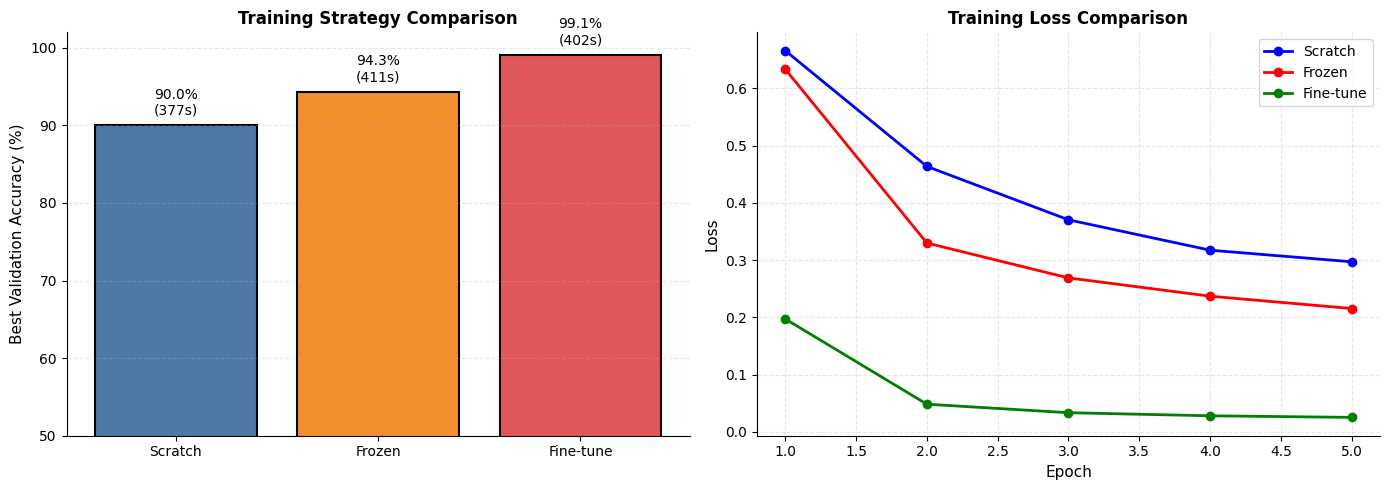

Visualization completed!


In [5]:
# 可视化对比图表
print("\n正在生成可视化对比图表...")

# 确保matplotlib在notebook中正确显示
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100
matplotlib.rcParams['savefig.dpi'] = 150
matplotlib.rcParams['font.size'] = 10

# 设置字体 - 使用英文标签避免中文乱码问题
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica', 'Verdana']
matplotlib.rcParams['axes.unicode_minus'] = False

# 创建对比图表
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 子图1：最佳准确率对比
labels = ['Scratch', 'Frozen', 'Fine-tune']
accs = [max(acc_scratch), max(acc_frozen), max(acc_ft)]
times = [f"{time_scratch:.0f}s", f"{time_frozen:.0f}s", f"{time_ft:.0f}s"]
colors = ['#4e79a7', '#f28e2b', '#e15759']

bars = ax1.bar(labels, accs, color=colors, edgecolor='black', linewidth=1.5)
for bar, acc, t in zip(bars, accs, times):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{acc:.1f}%\n({t})', ha='center', fontsize=10, va='bottom')

ax1.set_ylim(50, 102)
ax1.set_ylabel('Best Validation Accuracy (%)', fontsize=11)
ax1.set_title('Training Strategy Comparison', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y', linestyle='--')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# 子图2：训练损失曲线对比
epochs = range(1, 6)
ax2.plot(epochs, loss_scratch, 'bo-', label='Scratch', linewidth=2, markersize=6)
ax2.plot(epochs, loss_frozen, 'ro-', label='Frozen', linewidth=2, markersize=6)
ax2.plot(epochs, loss_ft, 'go-', label='Fine-tune', linewidth=2, markersize=6)
ax2.set_xlabel('Epoch', fontsize=11)
ax2.set_ylabel('Loss', fontsize=11)
ax2.set_title('Training Loss Comparison', fontsize=12, fontweight='bold')
ax2.legend(loc='best', fontsize=10)
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# 添加一些统计信息
print(f"\nTraining Strategy Comparison Results:")
print(f"1. Scratch Training: Best Accuracy {max(acc_scratch):.1f}%, Training Time {time_scratch:.0f}s")
print(f"2. Frozen Features: Best Accuracy {max(acc_frozen):.1f}%, Training Time {time_frozen:.0f}s")
print(f"3. Fine-tuning: Best Accuracy {max(acc_ft):.1f}%, Training Time {time_ft:.0f}s")

# 调整布局并保存
plt.tight_layout()
plt.savefig('task_d_final_comparison.png', dpi=150, bbox_inches='tight')
print(f"\nChart saved as 'task_d_final_comparison.png'")

# 显示图表
plt.show()
print("Visualization completed!")